# results_analysis_figures.ipynb
- notebook purpose: analysis and figures 
- python 3.13.7

### imports

In [10]:
import os, sys
import itertools
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import ScaledTranslation
import itertools

In [ ]:
os.chdir(os.path.expanduser("insert_parent_directory"))
sys.path.append("insert_parent_directory"))
from DaylongSampling.daylongtranscript_public import* # <-- daylongtranscript.py

In [ ]:
# TABLE 2: transcript descriptives 
transcript_fpath = f"directory_to_cleaned_transcripts" # use clean_transcript.py to clean transcripts txt files 
FamilyA_files = [f"transcriptA1.txt", f"transcriptA2.txt", f"transcriptA3.txt"]

transcriptA1 = DaylongTranscript(fpath = transcript_fpath+FamilyA_files[0], fname = FamilyA_files[0], isVanDam=False)
transcriptA1.describe()
transcriptA2 = DaylongTranscript(fpath = transcript_fpath+FamilyA_files[1], fname = FamilyA_files[1], isVanDam=False)
transcriptA2.describe()
transcriptA3 = DaylongTranscript(fpath = transcript_fpath+FamilyA_files[2], fname = FamilyA_files[2], isVanDam=False)
transcriptA3.describe()

FamilyB_files = [f"{transcriptB1.txt}", f"{transcriptB2.txt}"]
transcriptB1 = DaylongTranscript(fpath = transcript_fpath+FamilyB_files[0], fname = FamilyB_files[0], isVanDam=False)
transcriptB1.describe()

transcriptB2 = DaylongTranscript(fpath = transcript_fpath+FamilyB_files[1], fname = FamilyB_files[1], isVanDam=False)
transcriptB2.describe()

fname = "BN32_clean.txt" # VanDam 
transcriptC = DaylongTranscript(fpath = transcript_fpath+fname, fname = fname, isVanDam = True)
transcriptC.describe()


In [4]:
TRANSCRIPT_LABELS_DICT = {transcriptA1: "A1", transcriptA2: "A2", transcriptA3: "A3", transcriptB1: "B1", transcriptB2: "B2", transcriptC: "C"}
TRANSCRIPTS = list(TRANSCRIPT_LABELS_DICT.keys())
TRANSCRIPT_LABELS = list(TRANSCRIPT_LABELS_DICT.values())

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

### visualization & plotting functions

In [18]:
COLOR_PAL_DICT = {'blue':'#0077BB', 'cyan': '#33BBEE', "teal": '#009988', 'orange':'#EE7733', 'red':'#CC3311', 'magenta':'#EE3377'}
COLOR_PAL_LIST = list(COLOR_PAL_DICT.values())
COLOR_PAL_DEF = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988']

In [17]:
def grp_means_stds(group):
    return group.mean(), group.std()

def make_errorplots(df, sampled_feature = "[sampled feature]", subtitle = 'sampling interval size = 30 seconds', 
                    x_label = "total time sampled (minutes)", save = False, plot_proptts = True):
    ''' 
    - makes two panel percent error plots (panel 1: overall error; panel 2: individual transcript error)
    '''
    df_2 = df.drop("Transcript", axis = 1)
    df_stats = df_2.describe()
    overall_mean = df_2.mean()
    overall_std = df_2.std()
    range = np.array([overall_mean - df_stats.loc['min'],  df_stats.loc['max'] - overall_mean])
    iqr = np.array([overall_mean - df_stats.loc['25%'], df_stats.loc['75%'] - overall_mean])
    middle_90 = np.array([overall_mean - df_2.quantile(0.05), df_2.quantile(0.95) - overall_mean])
    fig,axes = plt.subplots(1,2, figsize = (12,5), dpi = 500, sharey = False)
    color_list = [COLOR_PAL_DICT["blue"], COLOR_PAL_DICT["orange"], COLOR_PAL_DICT['red']]

    axes[0].errorbar(x = overall_mean.index,  y = overall_mean, marker="o", markerfacecolor=color_list[0], 
                    linestyle="--", color = color_list[0], label = "mean")
    axes[0].errorbar(x = overall_mean.index,  y = overall_mean, yerr = range, label="range", 
                    fmt = "none", ecolor = color_list[0],  capsize = 3)
    axes[0].errorbar(x = overall_mean.index,  y = overall_mean, yerr = np.abs(middle_90), label="90% of values", fmt = 'none',
                    ecolor = color_list[1], elinewidth = 5)
    axes[0].errorbar(x = overall_mean.index,  y = overall_mean, yerr = np.abs(iqr), label="50% of values", fmt = 'none',  
                    ecolor = color_list[2], elinewidth=10)
    axes[0].legend()
    axes[0].set_title("Across all Transcripts", fontweight = "bold")
    axes[0].set_ylabel("mean percent error", fontweight = "bold")
    axes[0].set_xlabel(f"{x_label}", fontweight = "bold")
    legend_properties = {'weight':'bold', 'size': 11}
    axes[0].legend(prop=legend_properties) 

    color_list = list(COLOR_PAL_LIST)
    grouped = df.groupby("Transcript")
    for i, transcript_key in enumerate(list(TRANSCRIPT_LABELS_DICT.values())):
        if transcript_key not in df["Transcript"].values: continue
        group =grouped.get_group(transcript_key)
        group = group.drop("Transcript", axis = 1)
        grp_means, grp_stds = grp_means_stds(group)
        axes[1].errorbar(x=grp_means.index, y=grp_means, label=transcript_key, marker = "o", markerfacecolor = color_list[i], color = color_list[i])
        legend_properties = {'weight':'bold', 'size': 11}
        axes[1].legend(prop=legend_properties) 
        axes[1].set_title("Individual Transcripts", fontweight = "bold")
        axes[1].set_xlabel(f"{x_label}", fontweight = "bold")

    for ax in axes:
        #lbls = [str(i) for i in overall_mean.index]
        #ax.set_xticks(list(overall_mean.index))
        if plot_proptts:
            x_vals = [int(xval * 100) for xval in list(overall_mean.index)]
        else: x_vals = list(overall_mean.index)
        ax.set_xticks(list(overall_mean.index))
        ax.set_xticklabels(x_vals,fontweight = 'bold',rotation = 10)
        ax.set_yticklabels(ax.get_yticklabels(),fontweight = 'bold')

    plt.suptitle(f"Mean Percent Error of Estimates {sampled_feature}\n{subtitle}", fontweight = "bold")
    plt.tight_layout()
    plt.show()

def plot_comparison(df1, df2, legend, prop_tts = False, shift = 0.5):
    # plot 
    fig,axes = plt.subplots(figsize = (12,5), dpi = 500)#, sharey = False)
    
    df1 = df1.drop("Transcript", axis = 1)
    group1_means = df1.mean()
    print(group1_means)
    middle_90 = np.array([group1_means - df1.quantile(0.05), df1.quantile(0.95) - group1_means])
    x_vals = np.array(group1_means.index)
    axes.errorbar(x=x_vals -shift, y=group1_means, yerr = middle_90,label=legend[0], marker = "o",
                alpha=.89, fmt=':', capsize=3, capthick=1 )#, markerfacecolor = color_list[i], color = color_list[i])

    df2 = df2.drop("Transcript", axis = 1)
    group2_means = df2.mean()
    print(group2_means)
    middle_90 = np.array([group2_means - df2.quantile(0.05), df2.quantile(0.95) - group2_means])
    axes.errorbar(x=x_vals + shift, y=group2_means, yerr = middle_90,label=legend[1], marker = "s",
                alpha=.89, fmt=':', capsize=3, capthick=1 )#, markerfacecolor = color_list[i], color = color_list[i])
    legend_properties = {'weight':'bold', 'size': 11}
    axes.legend(prop=legend_properties) 
    plt.xticks(list(list(group1_means.index)))
    plt.setp(axes.get_xticklabels(), fontsize=12, fontweight='bold')
    plt.setp(axes.get_yticklabels(), fontsize=12, fontweight='bold')

    axes.set_ylabel("mean percent error", fontsize = 12, fontweight = 'bold')
    if prop_tts:
        axes.set_xlabel("total sampled time (% of recording)", fontsize = 12, fontweight = 'bold', labelpad = 10)
    else:
         axes.set_xlabel("total sampled time (minutes)", fontsize = 12, fontweight = 'bold', labelpad = 10)
    #axes.set_title("Mean percent estimate error with and without sample replacement\nsampling interval size = 30 seconds", fontweight = "bold")
    plt.show()

def mean_error_difference(df1, df2, as_degree = False, return_diff = False):
    if 'Transcript' in df1.columns: df1 = df1.drop("Transcript", axis = 1)
    if 'Transcript' in df2.columns: df2 = df2.drop("Transcript", axis = 1)
    if as_degree: diff = df1.mean() / df2.mean()
    else: diff = df1.mean() - df2.mean()
    print(np.array(diff))
    print(diff.describe())
    if return_diff: return diff.describe()
    else: return

def make_selectfeatures_errorplot(allspeech, selectfeatures, groupby_column = "Frequency Density Group", hue_order = ["rare", "low", "medium", "high", "very high", "all speech"],
        colors_list = ['#DDAA33',  '#66CCEE', '#4477AA', '#228833', '#AA3377', '#332288'],
          xvals = [0.05, 0.1, 0.15,0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], title = ""): 
    allspeech[groupby_column] = "all speech"
    all_features = pd.concat([allspeech, selectfeatures])
    x_vals = xvals
    # make data long format
    df_long = all_features.melt( id_vars=groupby_column, value_vars=x_vals,
                    var_name="tts", value_name="perr" )
    df_means = ( df_long.groupby([groupby_column, "tts"], as_index=False)["perr"].mean())

    # plot 
    fig,ax = plt.subplots(figsize = (12,5), dpi = 500)
    sns.lineplot( data=df_means, x="tts", y="perr",
                hue=groupby_column,  marker="o", palette=colors_list, hue_order = hue_order, markersize =8 )
    plt.xticks(x_vals)
    x_vals = [int(xval * 100) for xval in x_vals]
    ax.set_xticklabels(x_vals,fontweight = 'bold')
    ax.set_yticklabels(ax.get_yticklabels(),fontweight = 'bold')
    legend_properties = {'weight':'bold', 'size': 11}
    ax.legend(title = groupby_column, prop=legend_properties, title_fontproperties={'weight':'bold', 'size':11})
    plt.xlabel("total time sampled (% of recording)", fontweight = "bold")
    plt.ylabel("mean percent estimate error", fontweight = "bold")
    plt.title(title, fontweight = "bold")
    plt.show()
    return

def get_feature_density(transcript, feature_dict):
    raw_amount = transcript.feature_count(feature_dict = feature_dict)
    denom_feature = 0
    # calculate density by either using overall word counts or utterance counts, depending on feature type 
    if list(feature_dict.keys())[0] == "utterance_annotation":
        denom_feature = len(transcript.utterances)
    else: denom_feature = transcript.get_total_word_count()
    density = raw_amount / denom_feature 
    return raw_amount, density 

def get_feature_densities(feature_dicts, transcripts = list(TRANSCRIPT_LABELS_DICT.keys()), transcript_labels = list(TRANSCRIPT_LABELS_DICT.values())):
    '''
    - wrapper function for get_feature_density
    '''
    C_xds_codes = {"T": "id", "A": "od", "C": None, 'O': None, 'U': None}
    densities = []
    for feature_dict in feature_dicts:
        feature_type = list(feature_dict.keys())[0]
        feature = list(feature_dict.values())[0]  
        indiv_feature_density = []     
        print(f"Feature densities for: {feature_type}, {feature}")
        for i, transcript in enumerate(transcripts):
            if transcript_labels[i] == "C": 
                if feature_type == "utterance_annotation": continue 
                elif feature_type == "xds": 
                    feature = C_xds_codes[feature]
                    feature_dict = {"xds": feature}
            raw_amount, density = get_feature_density(transcript, feature_dict)
            indiv_feature_density.append(density)
            densities.append(density)
            print(f"\t{transcript_labels[i]:<5}: {raw_amount:<5} \t {density * 100}%")
        if len(indiv_feature_density) > 1: print(f"\tOverall: {statistics.mean(indiv_feature_density) * 100:<5}% \tStdev: {statistics.stdev(indiv_feature_density)*100}%")
    #print(f"\nGroup Mean: {statistics.mean(densities)*100:<5}% \tStdev: {statistics.stdev(densities)*100}%")
    return(densities)

In [16]:
def prop_of_samples(df, cols):
    ''' 
    - given a dataframe & total time sampled, will output proportion of samples greater than 2%, 5%, 10%, and 20% error
    '''
    print("Proportion of samples > x% error")
    for col in cols :
        temp_df = df[col]
        samples_2 = len(temp_df[temp_df>2]) / 600
        samples_5 = len(temp_df[temp_df>5]) / 600
        samples_10 = len(temp_df[temp_df>10]) / 600
        samples_20 = len(temp_df[temp_df>20]) / 600
        print(f'--{col} group\n> 2%: {samples_2:<25}\t> 5%: {samples_5:<25}\t > 10%: {samples_10:<25}\t>20%: {samples_20}')
        print()
    return

In [15]:
def eventplot(event_occurrences, event_label = "SET LABEL"):
    fig, ax = plt.subplots(figsize = (16,6), facecolor ='w') #dpi = 500,
    lineoffsets = [5.25, 5.25, 4.0, 4.0, 2.5, 2.5, 1.25, 1.25, 0.0, 0.0, -1.2, -1.2]
    y_ticks = [5.25, 4.0, 2.5, 1.25, 0.0, -1.2]
    speech_c = '#77AADD'
    event_c = '#EE3377'
    colors = [speech_c, event_c, speech_c, event_c, speech_c, event_c, speech_c, event_c, speech_c, event_c, speech_c, event_c]
    ax.eventplot(positions = event_occurrences, lineoffsets=lineoffsets, linelengths=0.8, 
                 colors = colors, alpha = 0.8, linewidths=1)
    ax.set_yticks(ticks = [5.25, 4.0, 2.5, 1.25, 0.0, -1.2], labels = list(TRANSCRIPT_LABELS_DICT.values()),
                fontweight = "bold", fontsize = 16)
    plt.setp(ax.get_xticklabels(), fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("time across recording (minutes) ", fontweight = "bold", fontsize = 16)
    plt.title(f"Occurrences of {event_label} across recordings",fontweight = "bold", fontsize = 16)
    plt.show()

def make_eventplot(feature_type, feature, plot_transcripts = list(TRANSCRIPT_LABELS_DICT.keys())):
    event_occurrences = [] # follows format of speech_dist, word_dist 
    feature_dict = {feature_type: feature}
    for transcript in list(TRANSCRIPT_LABELS_DICT.keys()):
        speech_dist =  [ i for i, x in enumerate(transcript.get_speech_distribution()) if x >= 1]
        if transcript in plot_transcripts: 
            word_dist = [ i for i, x in enumerate(transcript.get_feature_distribution(feature_dict = feature_dict)) if x >= 1]
        else: word_dist = []
        event_occurrences.append(speech_dist)
        event_occurrences.append(word_dist)
    eventplot(event_occurrences, event_label=f"{feature_type}\"{feature}\"")

## Fig 1

In [13]:
def speechdist(transcripts, save = False):
    fig, axs = plt.subplots(3,2, sharex = True, figsize = (10,5), dpi = 600)#, dpi = 1000)
    co = "#449DB3FF"
    #fig.suptitle("Speech Distributions", y = 0.98, fontweight = "bold")
    axs = axs.ravel()
    axs_i = 0
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams["axes.labelweight"] = 'bold'
    for i,( transcript, transcript_name) in enumerate(transcripts.items()):
        ax =  axs[i]
        speech_dist = transcript.get_speech_distribution()
        x = list(range(1, len(speech_dist)+1))
        y = speech_dist
        ax.bar(x, y, color = co, alpha = 1)#, alpha = 0.8)
        ax.set_ylabel("word count", fontweight = "bold", size=11)
        ax.text(-0.28, 0.5, f'\n{transcript_name}', transform=ax.transAxes, rotation=0, va='center', size = 15)


    axs[4].set_xlabel("time across recording (min)", size = 11, fontweight = "bold")    
    axs[-1].set_xlabel("time across recording (min)", size = 11, fontweight = "bold")    
    
    plt.tight_layout(h_pad = 1, w_pad = 2.5)

    plt.show()

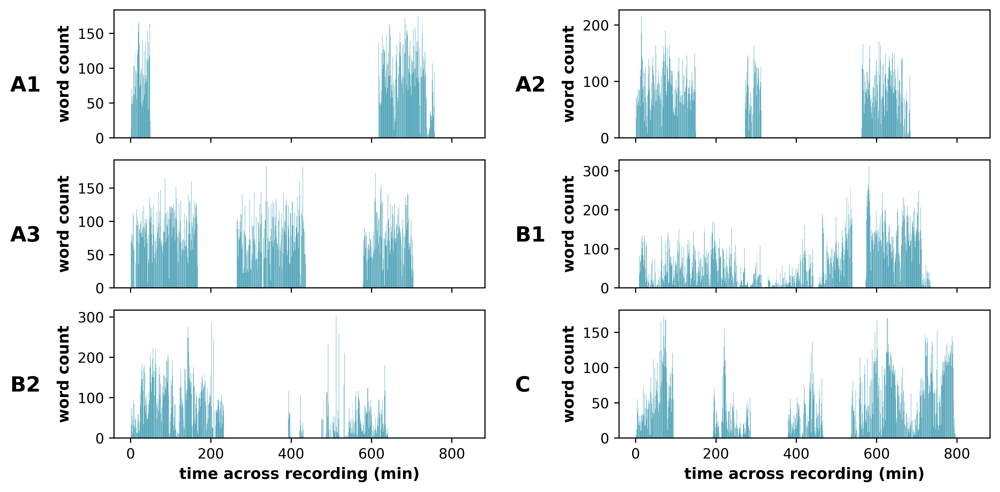

In [14]:
speechdist(TRANSCRIPT_LABELS_DICT)

# Part 1: Simulation & Evaluation of Sampling Interval Size & Total Sampled Time
- implementation of random sampling with replacement procedure

### read in csv data

In [11]:
analysis1_1_samplingintsize = pd.read_csv("DaylongSampling/Results/CSV/Analysis1_1_SamplingIntervalSize_EstimatePercentError.csv", 
                                 header = 0)
analysis1_2_tts_asminutes = pd.read_csv("DaylongSampling/Results/CSV/Analysis1_2_TotalTimeSampled_asMinutes_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)
analysis1_2_tts_asprop = pd.read_csv("DaylongSampling/Results/CSV/Analysis1_2_TotalTimeSampled_asProp_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)
analysis1_3_selectfeatures = pd.read_csv("DaylongSampling/Results/CSV/Analysis1_3_SelectFeatures_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)


## Analysis 1.1: Evaluating Accuracy across Varying Sampling Interval Size 


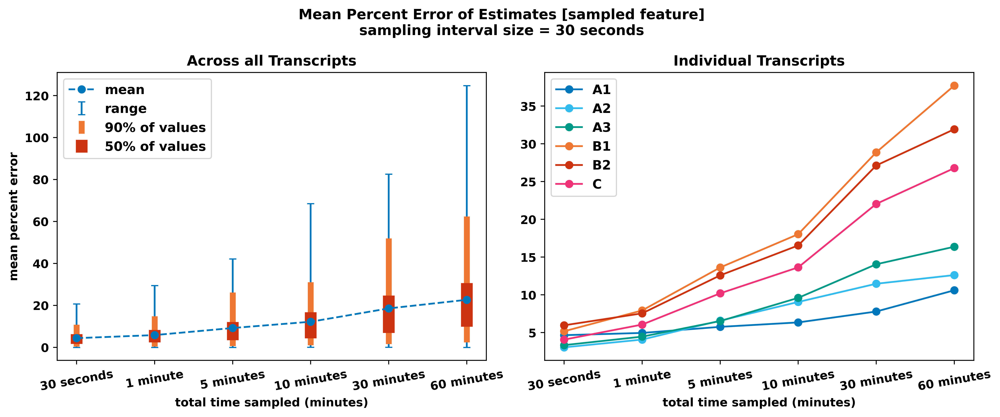

In [16]:
# Figure 2
make_errorplots(analysis1_1_samplingintsize, plot_proptts = False)

In [ ]:
# Table 4
prop_of_samples(analysis1_1_samplingintsize, cols = list(analysis1_1_samplingintsize.columns[:-1]))

Proportion of samples > x% error
--30 seconds group
> 2%: 0.6983333333333334       	> 5%: 0.3616666666666667       	 > 10%: 0.07166666666666667      	>20%: 0.0016666666666666668

--1 minute group
> 2%: 0.7983333333333333       	> 5%: 0.485                    	 > 10%: 0.16666666666666666      	>20%: 0.011666666666666667

--5 minutes group
> 2%: 0.855                    	> 5%: 0.6466666666666666       	 > 10%: 0.35333333333333333      	>20%: 0.11

--10 minutes group
> 2%: 0.885                    	> 5%: 0.73                     	 > 10%: 0.47                     	>20%: 0.19

--30 minutes group
> 2%: 0.9383333333333334       	> 5%: 0.8183333333333334       	 > 10%: 0.645                    	>20%: 0.33166666666666667

--60 minutes group
> 2%: 0.965                    	> 5%: 0.9                      	 > 10%: 0.7466666666666667       	>20%: 0.41333333333333333



In [18]:
analysis1_1_samplingintsize.describe()

,30 seconds,1 minute,5 minutes,10 minutes,30 minutes,60 minutes
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,4.380905,5.844788,9.215640,12.206262,18.561262,22.669777
std,3.547136,4.635529,7.767745,10.642610,15.928892,19.359403
min,0.006000,0.008000,0.013000,0.043000,0.032000,0.004000
25%,1.640000,2.406000,3.471250,4.306000,6.861250,9.891000
50%,3.627500,4.900500,7.141000,9.556500,14.288000,16.871000
75%,6.318500,8.299500,12.111750,16.764750,24.726000,30.637750
max,20.745000,29.431000,42.180000,68.538000,82.563000,124.774000


## Analysis 1.2: Evaluating Accuracy across Varying Total Sampled Times 

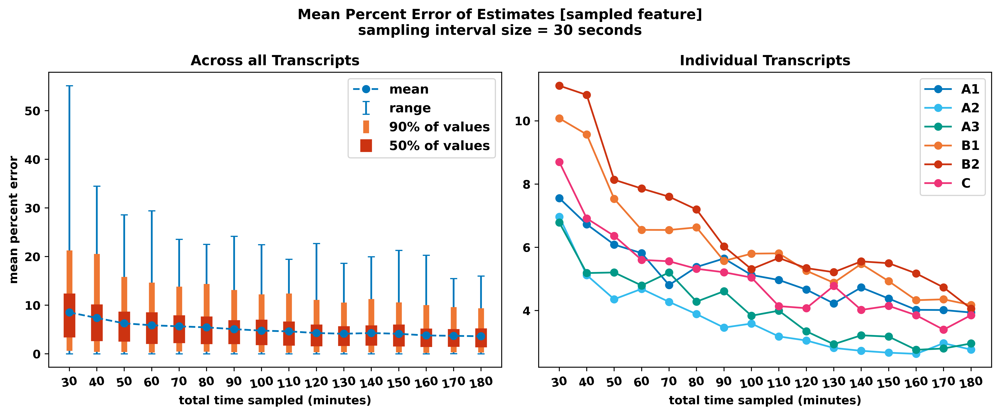

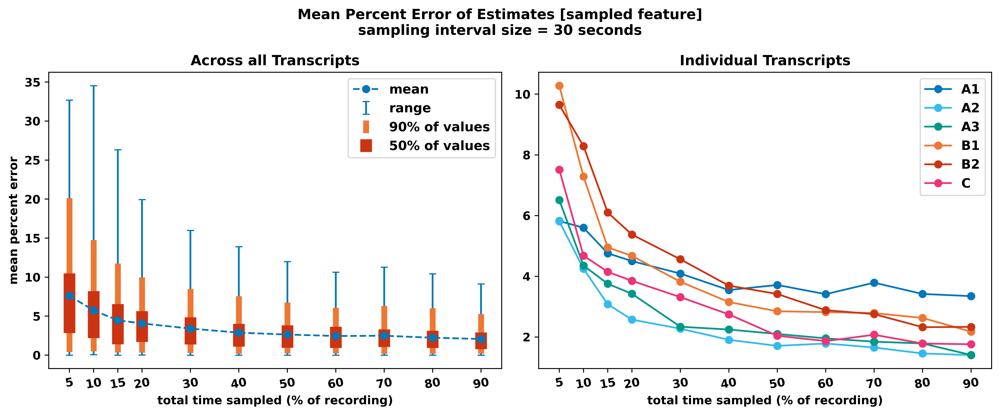

In [ ]:
# Figure 3
make_errorplots(analysis1_2_tts_asminutes, plot_proptts = False)
make_errorplots(analysis1_2_tts_asprop, x_label = "total time sampled (% of recording)", plot_proptts = True)

In [ ]:
# TABLE 5
prop_of_samples(analysis1_2_tts_asprop, cols = list(analysis1_2_tts_asprop.columns)[:-1])

Proportion of samples > x% error
--0.05 group
> 2%: 0.815                    	> 5%: 0.59                     	 > 10%: 0.28                     	>20%: 0.051666666666666666

--0.1 group
> 2%: 0.775                    	> 5%: 0.4583333333333333       	 > 10%: 0.17833333333333334      	>20%: 0.013333333333333334

--0.15 group
> 2%: 0.6716666666666666       	> 5%: 0.37                     	 > 10%: 0.08333333333333333      	>20%: 0.0033333333333333335

--0.2 group
> 2%: 0.685                    	> 5%: 0.30833333333333335      	 > 10%: 0.04833333333333333      	>20%: 0.0

--0.3 group
> 2%: 0.6333333333333333       	> 5%: 0.23333333333333334      	 > 10%: 0.021666666666666667     	>20%: 0.0

--0.4 group
> 2%: 0.555                    	> 5%: 0.16166666666666665      	 > 10%: 0.015                    	>20%: 0.0

--0.5 group
> 2%: 0.51                     	> 5%: 0.15                     	 > 10%: 0.0033333333333333335    	>20%: 0.0

--0.6 group
> 2%: 0.49833333333333335      	> 5%: 0.115           

In [21]:
analysis1_2_tts_asprop.describe()

,0.05,0.1,0.15,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,7.596878,5.741340,4.465197,4.065937,3.399567,2.882458,2.638985,2.454127,2.485233,2.234265,2.072327
std,6.191677,4.792627,3.832878,3.224007,2.641115,2.401360,2.186074,1.877545,1.885563,1.802783,1.614028
min,0.008000,0.060000,0.007000,0.012000,0.004000,0.004000,0.005000,0.001000,0.003000,0.006000,0.001000
25%,2.836000,2.190000,1.403250,1.688500,1.368500,1.103000,0.940250,0.914750,1.052250,0.924750,0.782500
50%,6.182500,4.480000,3.416000,3.392000,2.814500,2.244000,2.073000,1.990500,2.108000,1.764500,1.824000
75%,10.478750,8.218750,6.552500,5.643250,4.859250,4.008000,3.827250,3.646250,3.307000,3.143750,2.915000
max,32.679000,34.524000,26.321000,19.944000,15.987000,13.892000,11.980000,10.631000,11.288000,10.414000,9.135000


## Analysis 1.3: Estimating other features of varying frequency
 - 5% to 90% total sampled time
 - 30 second sampling intervals 

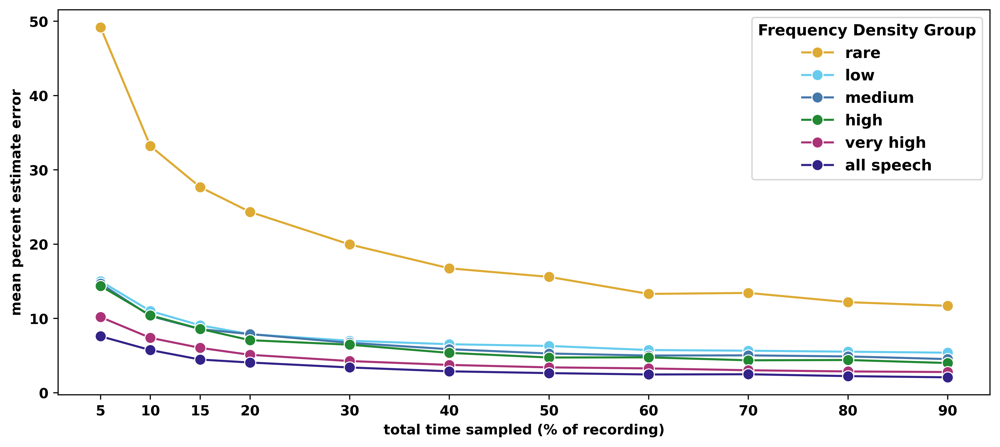

In [22]:
# Figure 5
df_allspeech = analysis1_2_tts_asprop.drop(columns = ["Transcript"])
df_features = analysis1_3_selectfeatures.drop(columns=[ "Transcript", "Feature"])
make_selectfeatures_errorplot(allspeech = df_allspeech, selectfeatures = df_features)

In [23]:
df_features.groupby(["Frequency Density Group"]).describe()

0.05                                        \
                          count       mean        std    min      25%   
Frequency Density Group                                                 
high                      900.0  14.373767  11.697292  0.006   5.1370   
low                      1000.0  15.009308  13.633696  0.002   5.6490   
medium                   1000.0  14.683963  12.504371  0.008   5.7720   
rare                     1100.0  49.181136  42.707483  0.000  17.7350   
very high                1000.0  10.181993   9.161854  0.013   3.6245   

                                                        0.1             ...  \
                             50%       75%      max   count       mean  ...   
Frequency Density Group                                                 ...   
high                     11.7465  20.81450   64.265   900.0  10.418324  ...   
low                      11.6705  20.28900  102.986  1000.0  10.997770  ...   
medium                   11.7420  20.18700   90.637  1000.0  10.324503  ...   
rare                     41.2500  67.25600  350.000  1100.0  33.202975  ...   
very high                 7.7405  13.96625   62.777  1000.0   7.387871  ...   

                              0.8             0.9                              \
                              75%     max   count       mean       std    min   
Frequency Density Group                                                         
high                      6.16800  24.182   900.0   3.995712  3.217028  0.008   
low                       7.96050  27.260  1000.0   5.386867  3.905053  0.009   
medium                    6.86275  16.697  1000.0   4.526531  3.089534  0.001   
rare                     17.05850  74.824  1100.0  11.695725  9.721935  0.000   
very high                 4.08800  15.799  1000.0   2.784865  2.353803  0.011   

                                                            
                             25%     50%       75%     max  
Frequency Density Group                                     
high                     1.48625  3.2515   5.68450  18.625  
low                      2.27550  4.5605   7.93700  19.214  
medium                   2.12200  4.0580   6.35925  18.667  
rare                     4.65500  9.1790  16.55525  71.382  
very high                0.97775  2.0870   4.07125  14.409  

[5 rows x 88 columns]

In [24]:
# error_diffs 
freqdensity = ["rare", "low", "medium", "high", "very high"]
df_allspeech = analysis1_2_tts_asprop.drop(columns = [0.15, "Transcript"])
df_features = analysis1_3_selectfeatures.drop(columns=[0.15, "Transcript", "Feature"])
for density_group in freqdensity: 
    group = df_features[df_features["Frequency Density Group"] == density_group]
    #group = group.drop(columns=["Frequency Density Group"])
    #error_diff = list(group.mean() / df_allspeech.mean())
    print(f'{density_group}')#\n\tmean: {statistics.mean(error_diff)}, std: {statistics.stdev(error_diff)}')
    mean_error_difference(df1 = group.drop(columns=["Frequency Density Group"]), 
                            df2 = df_allspeech, as_degree = True)
    print()

rare
[6.47386126 5.78314027 5.98486763 5.86956626 5.80973438 5.90868734
 5.41976322 5.40419789 5.4561258  5.64376536]
count    10.000000
mean      5.775371
std       0.323716
min       5.404198
25%       5.503036
50%       5.796437
75%       5.898907
max       6.473861
dtype: float64

low
[1.97572047 1.91554062 1.93841534 2.0573878  2.26508842 2.38504387
 2.34156007 2.27540083 2.47218392 2.59942947]
count    10.000000
mean      2.222577
std       0.238681
min       1.915541
25%       1.996137
50%       2.270245
75%       2.374173
max       2.599429
dtype: float64

medium
[1.93289432 1.7982741  1.94015295 1.97530499 2.03165018 2.00014058
 2.0393658  2.02280725 2.18578862 2.18427484]
count    10.000000
mean      2.011065
std       0.115330
min       1.798274
25%       1.948941
50%       2.011474
75%       2.037437
max       2.185789
dtype: float64

high
[1.89206224 1.81461548 1.73926139 1.90158321 1.86031946 1.79558513
 1.93991074 1.75539654 1.97115731 1.92812856]
count    10.000000
mean

### event plots 

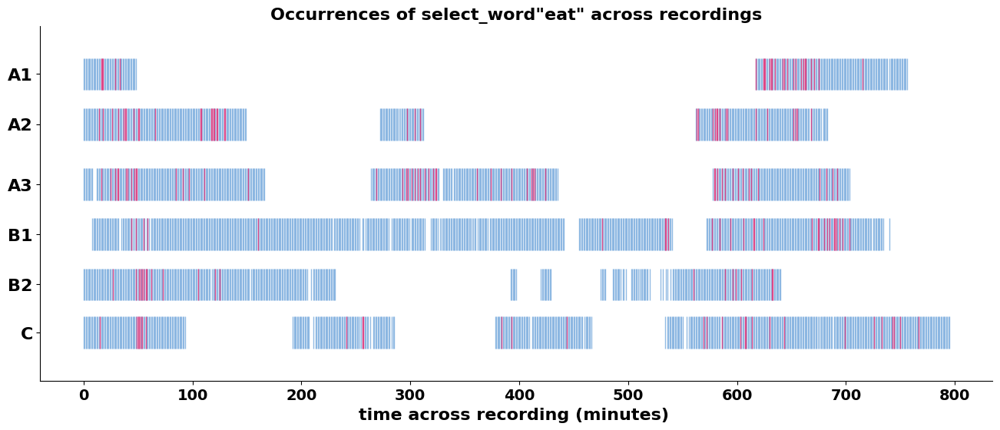

In [ ]:
# Figure 4
make_eventplot(feature_type = "select_word", feature = "eat")

# Part 2: Evaluation and Simulation of Sampling Procedures
- Random vs Systematic Sampling

### read in csv data

In [22]:
## daylong word count estimates 
analysis2_1_systematicsampling = pd.read_csv("DaylongSampling/Results/CSV/Analysis2_1_SystematicSampling_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)
analysis2_1_ss_30sec = analysis2_1_systematicsampling[analysis2_1_systematicsampling["Sampling Interval"] == "30 seconds"].drop(["Sampling Interval"], axis = 1)
analysis2_1_ss_5min = analysis2_1_systematicsampling[analysis2_1_systematicsampling["Sampling Interval"] == "5 minutes"].drop(["Sampling Interval"], axis = 1)

analysis2_1_rs_noreplacement = pd.read_csv("DaylongSampling/Results/CSV/Analysis2_1_RandomSamplingwithoutReplacement_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)
analysis2_1_rs_noreplacement_30sec = analysis2_1_rs_noreplacement[analysis2_1_rs_noreplacement["Sampling Interval"] == "30 seconds"].drop(["Sampling Interval"], axis = 1)
analysis2_1_rs_noreplacement_5min = analysis2_1_rs_noreplacement[analysis2_1_rs_noreplacement["Sampling Interval"] == "5 minutes"].drop(["Sampling Interval"], axis = 1)

analysis2_1_rs_comparison = pd.read_csv("DaylongSampling/Results/CSV/Analysis2_1_RandomSamplingComparison_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)
analysis2_1_rs_comparison_30sec = analysis2_1_rs_comparison[analysis2_1_rs_comparison["Sampling Interval"] == "30 seconds"].drop(["Sampling Interval"], axis = 1)
analysis2_1_rs_comparison_5min = analysis2_1_rs_comparison[analysis2_1_rs_comparison["Sampling Interval"] == "5 minutes"].drop(["Sampling Interval"], axis = 1)


In [23]:
## select feature estimates 
analysis2_2_ss_selectfeatures = pd.read_csv("DaylongSampling/Results/CSV/Analysis2_2_SystematicSampling_SelectFeatures_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)
analysis2_2_rs_noreplacement_selectfeatures = pd.read_csv("DaylongSampling/Results/CSV/Analysis2_2_RandomSamplingwithoutReplacement_SelectFeatures_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)
analysis2_2_rs_comparison_selectfeatures = pd.read_csv("DaylongSampling/Results/CSV/Analysis2_2_RandomSamplingComparison_SelectFeatures_EstimatePercentError.csv", header = 0 ).rename(columns=lambda x: pd.to_numeric(x, errors='ignore') , inplace=False)

## Analysis 2.1: Comparing Sampling Methods for Daylong Word Counts (overall speech)
 - for: daylong word counts
 - sampling intervals: 30 seconds, 5 minutes
 - total sampled time: 5% - 40% of recording
 - systematic, random sampling w/out replacement, random sampling w/ replacement (origina/comparison)

In [20]:
def plot_errors_procedures(df_long, title = ""):
    fig,axes = plt.subplots(ncols = 2, figsize = (13,5), dpi = 500,sharey = True)
    sampling_intervals = ["5 minutes", "30 seconds"]
    color_list = ["#D55E00",'#009988',"#0072B2"]
    marker_list = ["o", "D", "s"]
    for i, ax in enumerate(axes):
        with sns.plotting_context("talk",rc={'lines.linewidth': 0.8}):
        #with plt.rc_context({'lines.linewidth': 0.8}):
            sns.pointplot(data=df_long[df_long["Sampling Interval"] == sampling_intervals[i]], x = "Proportion Sampled", y = "Estimate Error", 
                    hue = "Sampling Procedure",ax = ax, errorbar= (("pi", 90)), 
                    dodge=0.5, linestyles = ":", capsize=.1, alpha = 0.9, palette = color_list, markers = marker_list,
                    markersize=6, err_kws={'linewidth': 1.5})
        #ax.set_title(f"Sampling Interval Size: {sampling_intervals[i]}", fontweight = "bold")
        ax.legend()
        ax.legend(prop={'weight':'bold', 'size': 11})
        ax.set_xticklabels(['5', '10', '15', '20', '30', '40'])
        if ax == axes[0]: ax.set_ylabel("mean percent error", fontsize = 12, fontweight = 'bold',labelpad = 10)
        else: ax.tick_params(labelleft=True)
        ax.set_xlabel("total sampled time (% of recording)", fontsize = 12, fontweight = 'bold', labelpad = 10)

        plt.setp(ax.get_xticklabels(), fontsize=12, fontweight='bold')
        plt.setp(ax.get_yticklabels(), fontsize=12, fontweight='bold')
        plt.setp(ax.lines, alpha=0.8)
    plt.suptitle(title)
    plt.tight_layout(w_pad=1, h_pad = 2)
    plt.show()

In [21]:
def prop_of_samples2(df, cols):
    ''' 
    - given a dataframe & total time sampled, will output proportion of samples greater than 2%, 5%, 10%, and 20% error
    '''
    print("Proportion of samples > x% error")
    for col in cols :
        temp_df = df[col]
        total_samples = len(temp_df)
        samples_2 = len(temp_df[temp_df>2]) / total_samples
        samples_5 = len(temp_df[temp_df>5]) / total_samples
        samples_10 = len(temp_df[temp_df>10]) / total_samples
        samples_20 = len(temp_df[temp_df>20]) / total_samples
        print(f'--{col} group\n> 2%: {samples_2:<25}\t> 5%: {samples_5:<25}\t > 10%: {samples_10:<25}\t>20%: {samples_20}')
        print()
    return

In [24]:
analysis2_1_rs_comparison["Sampling Procedure"] = "Random with replacement"
analysis2_1_rs_noreplacement["Sampling Procedure"] = "Random without replacement"
analysis2_1_systematicsampling["Sampling Procedure"] = "Systematic"
analysis_2_1 = pd.concat([analysis2_1_rs_comparison, analysis2_1_rs_noreplacement,analysis2_1_systematicsampling],ignore_index=True)
df_long = pd.melt(analysis_2_1, id_vars=['Transcript', 'Sampling Interval', 'Sampling Procedure'], var_name='Proportion Sampled', value_name='Estimate Error')
df_long

,Transcript,Sampling Interval,Sampling Procedure,Proportion Sampled,Estimate Error
0,B2,30 seconds,Random with replacement,0.05,13.271
1,B2,30 seconds,Random with replacement,0.05,11.734
2,B2,30 seconds,Random with replacement,0.05,14.718
3,B2,30 seconds,Random with replacement,0.05,15.930
4,B2,30 seconds,Random with replacement,0.05,13.227
...,...,...,...,...,...
21595,A2,5 minutes,Systematic,0.4,NaN
21596,A2,5 minutes,Systematic,0.4,NaN
21597,A2,5 minutes,Systematic,0.4,NaN
21598,A2,5 minutes,Systematic,0.4,NaN


### Figure 6

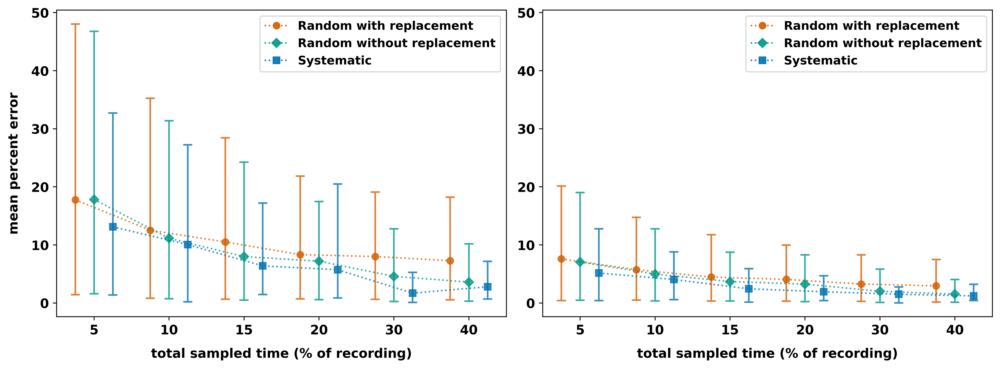

In [ ]:
## FIGURE 6
plot_errors_procedures(df_long)

### Table 7,8

In [25]:
analysis2_1_ss_5min.describe()

,0.05,0.1,0.15,0.2,0.3,0.4
count,600.000000,600.000000,600.000000,600.000000,500.000000,400.000000
mean,13.121050,10.046407,6.394505,5.724407,1.704336,2.801122
std,11.229296,9.075094,4.370925,5.494950,1.556718,2.125853
min,0.025000,0.006000,1.309000,0.765000,0.106000,0.680000
25%,5.692000,4.935000,2.446000,2.478000,0.741000,0.857000
50%,10.523000,7.892000,5.550000,3.912000,1.007000,2.036000
75%,18.052000,11.596000,8.303000,6.130000,2.183000,3.763000
max,58.302000,45.511000,17.880000,20.583000,5.266000,7.177000


In [26]:
analysis2_1_rs_noreplacement_5min.describe()

,0.05,0.1,0.15,0.2,0.3,0.4
count,600.000000,600.000000,600.000000,600.000000,500.000000,400.000000
mean,17.825335,11.142670,7.987058,7.200552,4.586002,3.601950
std,14.773645,9.646026,7.503726,5.717837,3.939824,3.423305
min,0.059000,0.050000,0.003000,0.080000,0.004000,0.004000
25%,6.549250,4.054000,2.836000,3.011750,1.674750,1.267750
50%,14.639000,8.328500,5.749000,6.137500,3.597500,2.473000
75%,24.849500,15.277500,10.460250,9.655500,6.440500,4.832250
max,87.362000,46.847000,41.705000,37.428000,24.952000,25.575000


In [27]:
analysis2_1_rs_comparison_5min.describe()

,0.05,0.1,0.15,0.2,0.3,0.4
count,600.000000,600.000000,600.000000,600.000000,500.000000,400.000000
mean,17.768913,12.521707,10.521008,8.326033,7.999416,7.291272
std,14.945234,11.438637,8.764438,6.902796,6.179842,5.651457
min,0.118000,0.038000,0.011000,0.015000,0.022000,0.069000
25%,6.272000,4.302250,4.097250,3.094250,3.198750,2.841000
50%,13.420000,9.703500,8.004500,6.482000,6.523500,6.331500
75%,26.288500,16.637500,15.070000,11.565250,11.511750,10.141250
max,96.262000,73.688000,50.754000,39.420000,33.404000,30.234000


In [141]:
print("random WITH replacement vs systematic: 5 min")
mean_error_difference(df1 = analysis2_1_rs_comparison_5min, 
                df2 = analysis2_1_ss_5min, as_degree = False)
print("\n\nrandom WITHOUT replacement vs systematic: 5 min")
mean_error_difference(df1 = analysis2_1_rs_noreplacement_5min, 
                df2 = analysis2_1_ss_5min, as_degree = False)
print("\n\nrandom WITH replacement vs random WITHOUT replacement : 5 min")
mean_error_difference(df1 = analysis2_1_rs_comparison_5min, 
                df2 = analysis2_1_rs_noreplacement_5min, as_degree = False)

random WITH replacement vs systematic: 5 min
[4.64786333 2.4753     4.12650333 2.60162667 6.29508    4.49015   ]
count    6.000000
mean     4.106087
std      1.425202
min      2.475300
25%      2.982846
50%      4.308327
75%      4.608435
max      6.295080
dtype: float64


random WITHOUT replacement vs systematic: 5 min
[4.704285   1.09626333 1.59255333 1.476145   2.881666   0.8008275 ]
count    6.000000
mean     2.091957
std      1.465261
min      0.800827
25%      1.191234
50%      1.534349
75%      2.559388
max      4.704285
dtype: float64


random WITH replacement vs random WITHOUT replacement : 5 min
[-0.05642167  1.37903667  2.53395     1.12548167  3.413414    3.6893225 ]
count    6.000000
mean     2.014131
std      1.450152
min     -0.056422
25%      1.188870
50%      1.956493
75%      3.193548
max      3.689323
dtype: float64


In [143]:
print("\nrandom WITH replacement vs systematic: 30 sec")
mean_error_difference(df1 = analysis2_1_rs_comparison_30sec, df2 = analysis2_1_ss_30sec, as_degree = False)
print("\nrandom WITHOUT replacement vs systematic: 30 sec")
mean_error_difference(df1 = analysis2_1_rs_noreplacement_30sec, df2 = analysis2_1_ss_30sec, as_degree = False)
print("\nrandom WITH replacement - random WITH replacement: 30 sec")
mean_error_difference(df1 = analysis2_1_rs_comparison_30sec, df2 = analysis2_1_rs_noreplacement_30sec, as_degree = False)


random WITH replacement vs systematic: 30 sec
[2.43543167 1.699025   2.018675   2.12690667 1.754332   1.7419    ]
count    6.000000
mean     1.962712
std      0.288190
min      1.699025
25%      1.745008
50%      1.886504
75%      2.099849
max      2.435432
dtype: float64

random WITHOUT replacement vs systematic: 30 sec
[1.90357333 0.94544667 1.23963167 1.31911333 0.507258   0.3113475 ]
count    6.000000
mean     1.037728
std      0.580891
min      0.311347
25%      0.616805
50%      1.092539
75%      1.299243
max      1.903573
dtype: float64

random WITH replacement - random WITH replacement: 30 sec
[0.53185833 0.75357833 0.77904333 0.80779333 1.247074   1.4305525 ]
count    6.000000
mean     0.924983
std      0.340089
min      0.531858
25%      0.759945
50%      0.793418
75%      1.137254
max      1.430552
dtype: float64


### Table 9

In [148]:
print("Prop of samples: systematic sampling")
prop_of_samples(df = analysis2_1_ss_30sec, cols = list(analysis2_1_ss_30sec.columns[:-1]) )
print("\n\nProp of samples: random sampling withOUT replacement")
prop_of_samples(df = analysis2_1_rs_noreplacement_30sec, cols = list(analysis2_1_rs_noreplacement_30sec.columns[:-1]))
print("\n\nProp of samples: random sampling WITH replacement")
prop_of_samples(df = analysis2_1_rs_comparison_30sec, cols = list(analysis2_1_rs_comparison_30sec.columns[:-1]))

Prop of samples: systematic sampling
Proportion of samples > x% error
--0.05 group
> 2%: 0.7416666666666667       	> 5%: 0.43                     	 > 10%: 0.115                    	>20%: 0.013333333333333334

--0.1 group
> 2%: 0.755                    	> 5%: 0.325                    	 > 10%: 0.0                      	>20%: 0.0

--0.15 group
> 2%: 0.5283333333333333       	> 5%: 0.1                      	 > 10%: 0.0                      	>20%: 0.0

--0.2 group
> 2%: 0.30833333333333335      	> 5%: 0.025                    	 > 10%: 0.0                      	>20%: 0.0

--0.3 group
> 2%: 0.25833333333333336      	> 5%: 0.0                      	 > 10%: 0.0                      	>20%: 0.0

--0.4 group
> 2%: 0.06166666666666667      	> 5%: 0.0                      	 > 10%: 0.0                      	>20%: 0.0



Prop of samples: random sampling withOUT replacement
Proportion of samples > x% error
--0.05 group
> 2%: 0.7783333333333333       	> 5%: 0.5383333333333333       	 > 10%: 0.2616666666

## Analysis 2.2: Random vs Systematic Sampling, Select Features
 - for: select feature counts
 - sampling intervals: 30 seconds
 - total sampled time: 5% - 40% of recording

### Figure 7

In [153]:
def plot_full_facetgrid(df_long, title = "", errorbar = "sd"):
    marker_map = {"Random with replacement": "o", "Random without replacement": "D", "Systematic": "s"} 
    dashes={"Random with replacement": "", "Random without replacement":(2, 2), "Systematic": (5, 2)}
    colors_list = ['#DDAA33',  '#66CCEE', '#4477AA', '#228833', '#AA3377', '#332288'] #["#D55E00",COLOR_PAL_DICT["teal"], "#0072B2"]
    with sns.plotting_context("talk",rc={"legend.fontsize": 12}):
        g = sns.relplot(data=df_long, x='Proportion Sampled', y='Estimate Error', col='Frequency Density Group', 
                col_order=["Rare", "Low", "Medium", "High", "Very High", "All Speech"], col_wrap = 3,
                kind='line', style = "Sampling Procedure", hue = "Sampling Procedure", 
                hue_order = ["Random with replacement", "Random without replacement", "Systematic"],
                markers=marker_map, markersize = 8, dashes=dashes, err_kws={'alpha': 0.15}, 
                errorbar = (("pi", 50)),palette = [COLOR_PAL_DICT["orange"], COLOR_PAL_DICT["teal"], COLOR_PAL_DICT["blue"]] )

        (g
        .set_axis_labels("total time sampled (% of recording)", "mean percent error", fontweight = "bold", fontsize = 13, labelpad = 10)
        .set_titles(template = "{col_name}", weight='bold')
        .set(xticks=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4], xticklabels = ["5","10","15","20","30","40"])
        .tight_layout(w_pad=1.3, h_pad = 2)
        .tick_params(labelbottom=True, labelleft=True)
        )


        for ax in g.axes.flat:
            ax.tick_params(axis='both', labelsize=11)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontweight('bold')

        handles, labels = g._legend.legend_handles, [t.get_text() for t in g._legend.get_texts()]
        sns.move_legend(g, "upper right", title = None, frameon = True, bbox_to_anchor=(0.8, 0.9))
        plt.setp(g._legend.get_texts(), fontweight='bold')
        leg2 = g.figure.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.8, 0.3), frameon = True,title=None)
        plt.setp(leg2.get_texts(), fontweight='bold')
        #for text in g.legend.get_texts(): text.set_fontsize(8)
        plt.suptitle(title)

In [151]:
xvals = [0.05, 0.1, 0.15, 0.2, 0.3,0.4, "Transcript"]
# add all speech to select features dataframes
df_ss_allspeech = analysis2_1_ss_30sec.copy()
df_rs_re_allspeech = analysis2_1_rs_comparison_30sec.copy()
df_rs_nore_allspeech = analysis2_1_rs_noreplacement_30sec.copy()
df_ss_allspeech["Frequency Density Group"] = "all speech"
df_rs_re_allspeech["Frequency Density Group"] = "all speech"
df_rs_nore_allspeech["Frequency Density Group"] = "all speech"

df_ss = pd.concat([df_ss_allspeech, analysis2_2_ss_selectfeatures],ignore_index=True)
df_ss["Sampling Procedure"] = "Systematic"

df_rs_re = pd.concat([df_rs_re_allspeech, analysis2_2_rs_comparison_selectfeatures],ignore_index=True)
df_rs_re["Sampling Procedure"] = "Random with replacement"

df_rs_nore = pd.concat([df_rs_nore_allspeech, analysis2_2_rs_noreplacement_selectfeatures],ignore_index=True)
df_rs_nore["Sampling Procedure"] = "Random without replacement"

df_concat = pd.concat([df_ss, df_rs_re, df_rs_nore], ignore_index=True)
df_long = pd.melt(df_concat, id_vars=['Transcript', 'Frequency Density Group', 'Feature','Sampling Procedure'], var_name='Proportion Sampled', value_name='Estimate Error')
#df_long["Proportion Sampled"] = df_long["Proportion Sampled"] * 100
df_long['Frequency Density Group'] = df_long['Frequency Density Group'].map(str.title)
df_long

,Transcript,Frequency Density Group,Feature,Sampling Procedure,Proportion Sampled,Estimate Error
0,B2,All Speech,NaN,Systematic,0.05,16.213
1,B2,All Speech,NaN,Systematic,0.05,8.152
2,B2,All Speech,NaN,Systematic,0.05,3.395
3,B2,All Speech,NaN,Systematic,0.05,20.488
4,B2,All Speech,NaN,Systematic,0.05,3.414
...,...,...,...,...,...,...
100795,A2,Very High,other-child directed speech,Random without replacement,0.4,NaN
100796,A2,Very High,other-child directed speech,Random without replacement,0.4,NaN
100797,A2,Very High,other-child directed speech,Random without replacement,0.4,NaN
100798,A2,Very High,other-child directed speech,Random without replacement,0.4,NaN


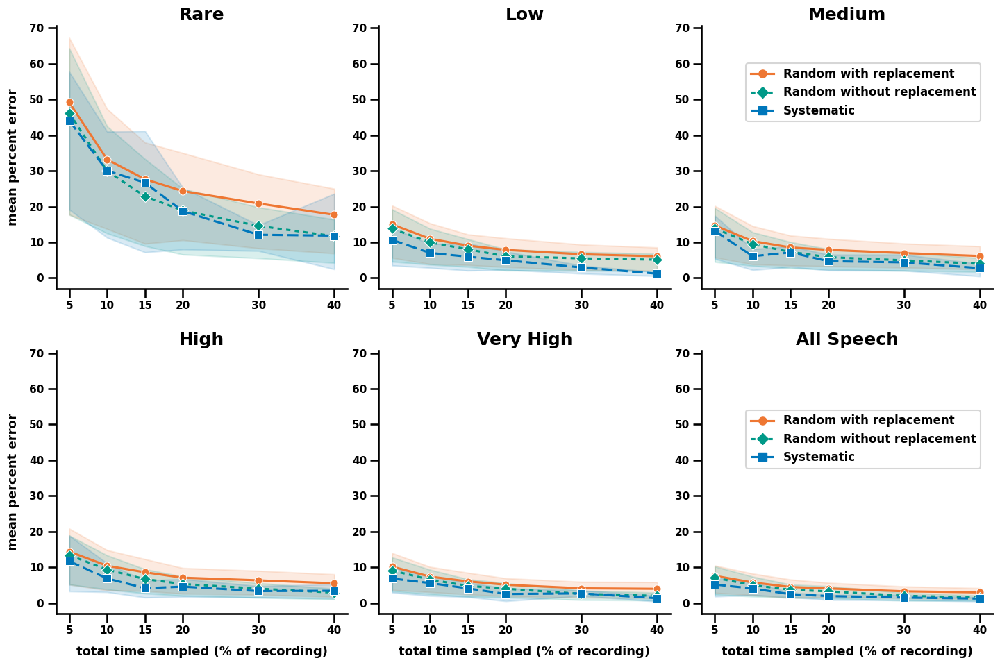

In [154]:
plot_full_facetgrid(df_long = df_long)

### Estimate Error Differences (Table 10,11)

In [28]:
# Table 10 
analysis2_2_rs_comparison_selectfeatures.groupby("Frequency Density Group").mean(numeric_only=True)

,0.05,0.1,0.15,0.2,0.3,0.4
Frequency Density Group,,,,,,
high,14.373767,10.418324,8.588773,7.071727,6.334520,5.503004
low,15.009308,10.997770,9.071169,7.881474,6.644827,6.084957
medium,14.683963,10.324503,8.560769,7.888539,6.975116,6.157639
rare,49.181136,33.202975,27.669644,24.334093,20.874754,17.690664
very high,10.181993,7.387871,6.037551,5.102816,4.100627,3.958967


In [29]:
analysis2_2_ss_selectfeatures.groupby("Frequency Density Group").mean(numeric_only=True)

,0.05,0.1,0.15,0.2,0.3,0.4
Frequency Density Group,,,,,,
high,11.699214,6.861001,4.136140,4.572164,3.334540,3.413744
low,10.686069,7.033935,5.978331,4.966913,2.961565,1.209075
medium,13.161764,6.107907,7.166384,4.711332,4.380575,2.762367
rare,44.080391,30.025234,26.704115,18.723175,12.103509,11.853639
very high,6.843149,5.575990,4.078226,2.507256,2.676401,1.333237


In [30]:
analysis2_2_rs_noreplacement_selectfeatures.groupby("Frequency Density Group").mean(numeric_only=True)

,0.05,0.1,0.15,0.2,0.3,0.4
Frequency Density Group,,,,,,
high,13.387378,9.331519,6.683989,5.303713,4.016877,2.891064
low,13.849845,9.976238,8.054507,6.074840,5.505295,5.131633
medium,13.875815,9.466437,7.290693,5.835309,4.950646,3.979293
rare,46.218400,29.962176,22.877370,18.904433,14.591657,11.701191
very high,9.090671,6.532225,4.793784,3.984474,2.548442,1.993402


In [ ]:
# Table 11
# how much more erroneous is estimate error for random sampling w/ replacement vs systematic sampling 
## random sampling with replacement - systematic sampling 
freqdensity = ["rare", "low", "medium", "high", "very high"]
df_ss = analysis2_2_ss_selectfeatures
df_rs = analysis2_2_rs_comparison_selectfeatures
for density_group in freqdensity: 
    group_ss = df_ss[df_ss["Frequency Density Group"] == density_group]
    group_rs = df_rs[df_rs["Frequency Density Group"] == density_group]
    print(f'{density_group}')#\n\tmean: {statistics.mean(error_diff)}, std: {statistics.stdev(error_diff)}')
    df_diff = mean_error_difference(df1 = group_rs.drop(columns=["Frequency Density Group", "Feature"]), 
                            df2 = group_ss.drop(columns=["Frequency Density Group", "Feature"]), as_degree = False, return_diff=True)
    
    print()
    print(df_diff["mean"], df_diff["std"])
    print()

rare
[5.10074545 3.17774091 0.96552909 5.61091818 8.77124556 5.83702571]
count    6.000000
mean     4.910534
std      2.640297
min      0.965529
25%      3.658492
50%      5.355832
75%      5.780499
max      8.771246
dtype: float64

4.9105341510341525 2.6402967499913803

low
[4.323239   3.963835   3.092838   2.914561   3.6832625  4.87588167]
count    6.000000
mean     3.808936
std      0.742344
min      2.914561
25%      3.240444
50%      3.823549
75%      4.233388
max      4.875882
dtype: float64

3.808936194444444 0.7423437406565511

medium
[1.522199   4.216596   1.394385   3.177207   2.59454125 3.39527143]
count    6.000000
mean     2.716700
std      1.105666
min      1.394385
25%      1.790285
50%      2.885874
75%      3.340755
max      4.216596
dtype: float64

2.7166999464285713 1.1056659757780396

high
[2.67455222 3.55732333 4.45263333 2.49956222 2.99998    2.08926   ]
count    6.000000
mean     3.045552
std      0.847833
min      2.089260
25%      2.543310
50%      2.837266
75%

In [ ]:
# how much more erroneous is estimate error for random sampling w/OUT replacement vs systematic sampling 
## random sampling without replacement - systematic sampling 
freqdensity = ["rare", "low", "medium", "high", "very high"]
df_ss = analysis2_2_ss_selectfeatures
df_rs = analysis2_2_rs_noreplacement_selectfeatures
for density_group in freqdensity: 
    group_ss = df_ss[df_ss["Frequency Density Group"] == density_group]
    group_rs = df_rs[df_rs["Frequency Density Group"] == density_group]
    print(f'{density_group}')#\n\tmean: {statistics.mean(error_diff)}, std: {statistics.stdev(error_diff)}')
    df_diff = mean_error_difference(df1 = group_rs.drop(columns=["Frequency Density Group", "Feature"]), 
                            df2 = group_ss.drop(columns=["Frequency Density Group", "Feature"]), as_degree = False, return_diff=True)
    
    print()
    print(df_diff["mean"], df_diff["std"])
    print()

rare
[ 2.13800909 -0.06305727 -3.82674455  0.18125818  2.48814778 -0.15244714]
count    6.000000
mean     0.127528
std      2.252484
min     -3.826745
25%     -0.130100
50%      0.059100
75%      1.648821
max      2.488148
dtype: float64

0.12752768157768082 2.2524842763096107

low
[3.163776   2.942303   2.076176   1.107927   2.54373    3.92255833]
count    6.000000
mean     2.626078
std      0.967878
min      1.107927
25%      2.193064
50%      2.743016
75%      3.108408
max      3.922558
dtype: float64

2.626078388888889 0.967877523869338

medium
[0.714051   3.35853    0.124309   1.123977   0.57007125 1.21692571]
count    6.000000
mean     1.184644
std      1.136131
min      0.124309
25%      0.606066
50%      0.919014
75%      1.193689
max      3.358530
dtype: float64

1.184643994047619 1.136131214594405

high
[ 1.68816333  2.47051778  2.54784889  0.73154889  0.68233714 -0.52268   ]
count    6.000000
mean     1.266289
std      1.191461
min     -0.522680
25%      0.694640
50%      1.

In [116]:
## how much more erroneous is estimate error for random sampling w/OUT replacement vs random sampling WITH replacement
## random sampling WITH replacement - WITHOUT replacement
freqdensity = ["rare", "low", "medium", "high", "very high"]
df_rs_nor = analysis2_2_rs_noreplacement_selectfeatures
df_rs_wr = analysis2_2_rs_comparison_selectfeatures
for density_group in freqdensity: 
    group_rs_nor = df_rs_nor[df_rs_nor["Frequency Density Group"] == density_group]
    group_rs_wr = df_rs_wr[df_rs_wr["Frequency Density Group"] == density_group]
    print(f'{density_group}')#\n\tmean: {statistics.mean(error_diff)}, std: {statistics.stdev(error_diff)}')
    df_diff = mean_error_difference(df1 = group_rs_wr.drop(columns=["Frequency Density Group", "Feature"]), 
                            df2 = group_rs_nor.drop(columns=["Frequency Density Group", "Feature"]), as_degree = False, return_diff=True)
    
    print()
    print(df_diff["mean"], df_diff["std"])
    print()

rare
[2.96273636 3.24079818 4.79227364 5.42966    6.28309778 5.98947286]
count    6.000000
mean     4.783006
std      1.401133
min      2.962736
25%      3.628667
50%      5.110967
75%      5.849520
max      6.283098
dtype: float64

4.783006469456471 1.4011332133289562

low
[1.159463   1.021532   1.016662   1.806634   1.1395325  0.95332333]
count    6.000000
mean     1.182858
std      0.315548
min      0.953323
25%      1.017880
50%      1.080532
75%      1.154480
max      1.806634
dtype: float64

1.1828578055555559 0.31554849866377105

medium
[0.808148   0.858066   1.270076   2.05323    2.02447    2.17834571]
count    6.000000
mean     1.532056
std      0.629082
min      0.808148
25%      0.961069
50%      1.647273
75%      2.046040
max      2.178346
dtype: float64

1.5320559523809523 0.6290823655814076

high
[0.98638889 1.08680556 1.90478444 1.76801333 2.31764286 2.61194   ]
count    6.000000
mean     1.779263
std      0.649189
min      0.986389
25%      1.257107
50%      1.836399
75

### 

# Supplemental Materials

### systematic sampling caveat

In [228]:
def make_crossprocedure_errorplots(df_long, feature = "", feature_density_group = ""):
    color_dict_transcripts = {"A1":'#0077BB', "A2":'#33BBEE', "A3":'#009988', "B1":'#EE7733', "B2":'#CC3311', "C":'#EE3377'} 
    fig,axes = plt.subplots(1,3, figsize = (13,4), dpi = 300, sharey = False)
    feature = feature
    density_group = feature_density_group
    print(density_group,  " ", feature)
    procedure_order = ["Systematic", "Random with replacement", "Random without replacement"]
    for i, p in enumerate(procedure_order):
        df_p = df_long[df_long["Sampling Procedure"] == p]
        df_p_f = df_p[(df_p["Frequency Density Group"] == density_group) & (df_p["Feature"] == feature)]
        sns.pointplot(data=df_p_f, x="Proportion Sampled", y="Estimate Error", 
                    hue = "Transcript", ax = axes[i], markers="o", errorbar = None, markersize=4, linewidth = 1, palette=color_dict_transcripts,
                    hue_order = TRANSCRIPT_LABELS)
        axes[i].set_ylabel("mean percent error", fontweight = "bold")
        axes[i].set_xlabel("total time sampled (% of recording)", fontweight = "bold")
        legend_properties = {'weight':'bold', 'size': 11}
        axes[i].legend(prop=legend_properties) 
        axes[i].set_title(f"{p}", fontweight = "bold")
    for ax in axes:
        #lbls = [str(i) for i in overall_mean.index]
        #ax.set_xticks(list(overall_mean.index))
        x_vals = ["5", "10", "15", "20", "30", "40"]#[int(xval) * 100 for xval in list(ax.get_xticklabels())]
        #ax.set_xticks(list(overall_mean.index))
        ax.set_xticklabels(x_vals,fontweight = 'bold')
        ax.set_yticklabels(ax.get_yticklabels(),fontweight = 'bold')
    plt.suptitle(f"Estimate Errors for {density_group} Feature: {feature}", fontweight = "bold")
    plt.tight_layout()
    plt.show()

In [203]:
xvals = [0.05, 0.1, 0.15, 0.2, 0.3,0.4, "Transcript"]
# add all speech to select features dataframes
df_ss_allspeech = analysis2_1_ss_30sec.copy()
df_rs_re_allspeech = analysis2_1_rs_comparison_30sec.copy()
df_rs_nore_allspeech = analysis2_1_rs_noreplacement_30sec.copy()
df_ss_allspeech["Frequency Density Group"] = "all speech"
df_rs_re_allspeech["Frequency Density Group"] = "all speech"
df_rs_nore_allspeech["Frequency Density Group"] = "all speech"

df_ss = pd.concat([df_ss_allspeech, analysis2_2_ss_selectfeatures],ignore_index=True)
df_ss["Sampling Procedure"] = "Systematic"

df_rs_re = pd.concat([df_rs_re_allspeech, analysis2_2_rs_comparison_selectfeatures],ignore_index=True)
df_rs_re["Sampling Procedure"] = "Random with replacement"

df_rs_nore = pd.concat([df_rs_nore_allspeech, analysis2_2_rs_noreplacement_selectfeatures],ignore_index=True)
df_rs_nore["Sampling Procedure"] = "Random without replacement"

df_concat = pd.concat([df_ss, df_rs_re, df_rs_nore], ignore_index=True)
df_long = pd.melt(df_concat, id_vars=['Transcript', 'Frequency Density Group', 'Feature','Sampling Procedure'], var_name='Proportion Sampled', value_name='Estimate Error')
#df_long["Proportion Sampled"] = df_long["Proportion Sampled"] * 100
df_long['Frequency Density Group'] = df_long['Frequency Density Group'].map(str.title)
df_long

,Transcript,Frequency Density Group,Feature,Sampling Procedure,Proportion Sampled,Estimate Error
0,B2,All Speech,NaN,Systematic,0.05,16.213
1,B2,All Speech,NaN,Systematic,0.05,8.152
2,B2,All Speech,NaN,Systematic,0.05,3.395
3,B2,All Speech,NaN,Systematic,0.05,20.488
4,B2,All Speech,NaN,Systematic,0.05,3.414
...,...,...,...,...,...,...
100795,A2,Very High,other-child directed speech,Random without replacement,0.4,NaN
100796,A2,Very High,other-child directed speech,Random without replacement,0.4,NaN
100797,A2,Very High,other-child directed speech,Random without replacement,0.4,NaN
100798,A2,Very High,other-child directed speech,Random without replacement,0.4,NaN


In [183]:
color_list = list(COLOR_PAL_LIST)
color_dict_transcripts = {"A1":'#0077BB', "A2":'#33BBEE', "A3":'#009988', "B1":'#EE7733', "B2":'#CC3311', "C":'#EE3377'} 
#['#0077BB', '#33BBEE', '#009988', '#EE7733', '#CC3311', '#EE3377']

Rare   select word


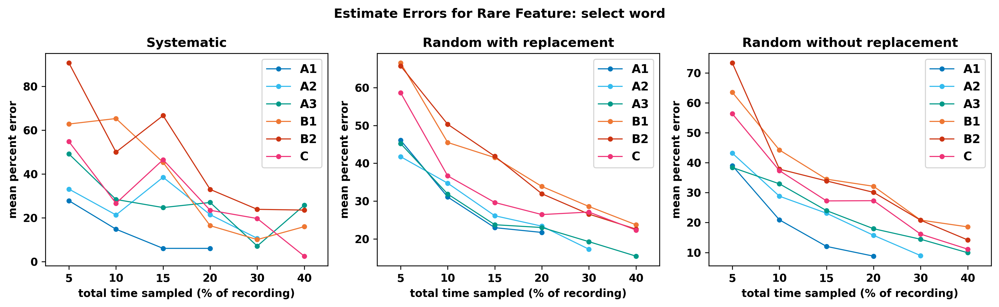

Rare   imitations


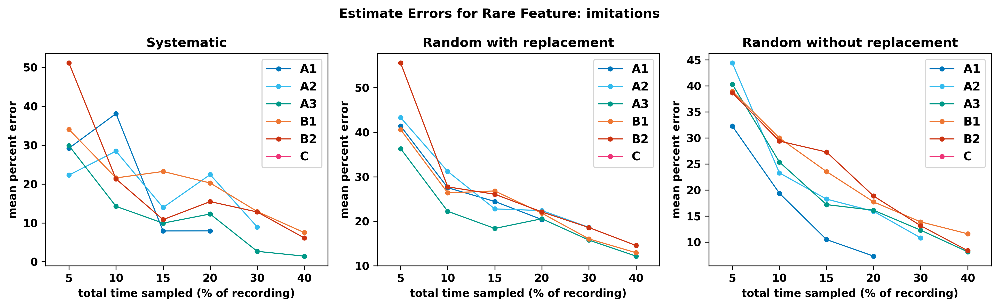

Low   exclamations


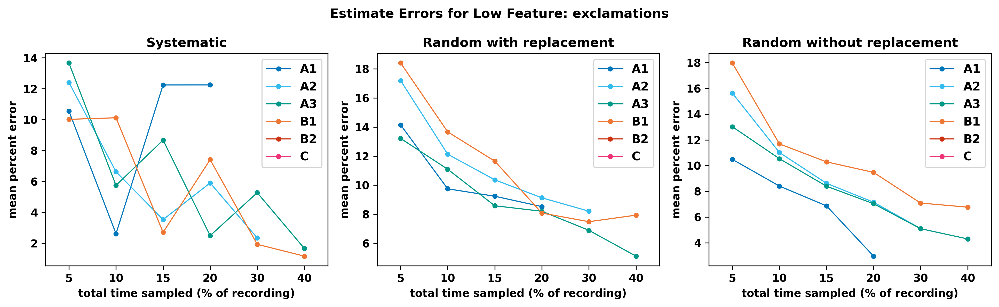

Low   target-child vocalizations


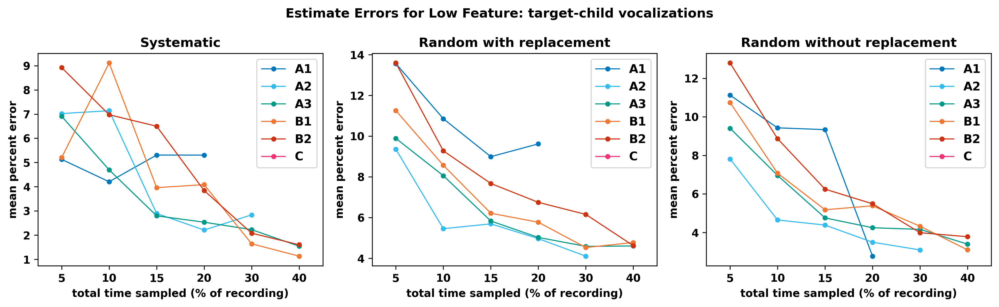

Low   other-child directed speech


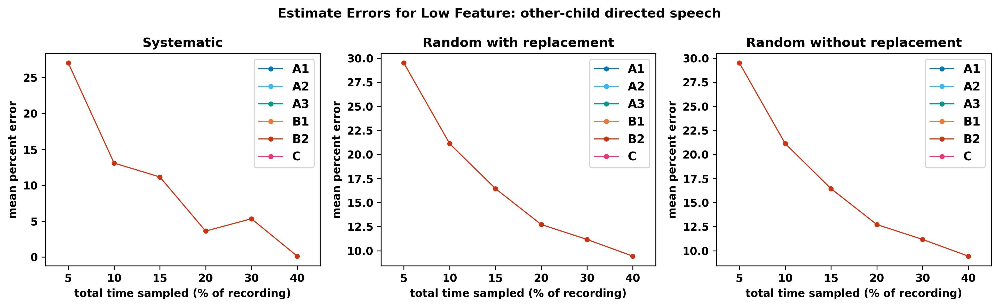

Medium   questions


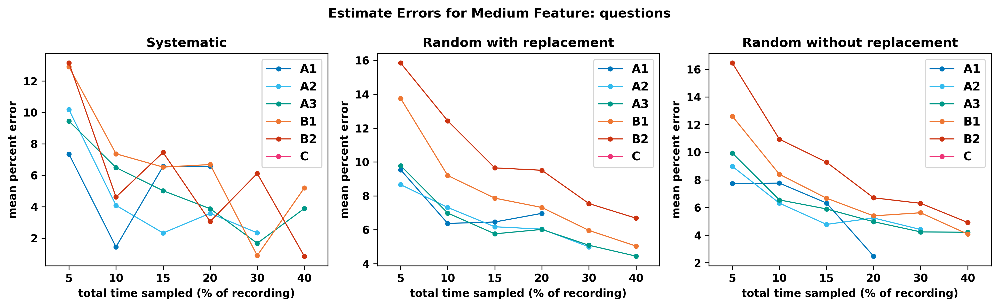

Medium   speech from non-target child


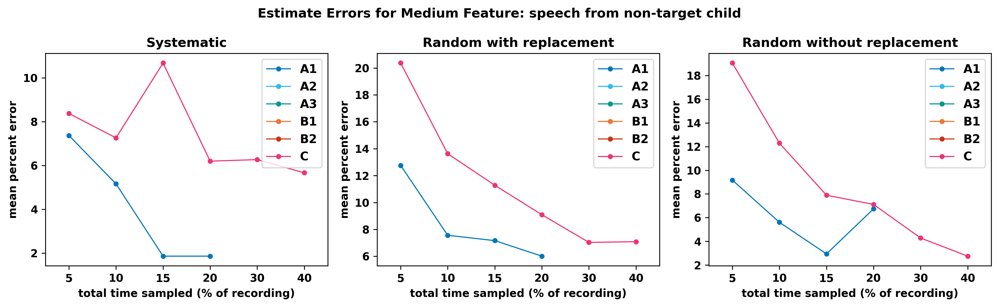

Medium   target-child directed speech


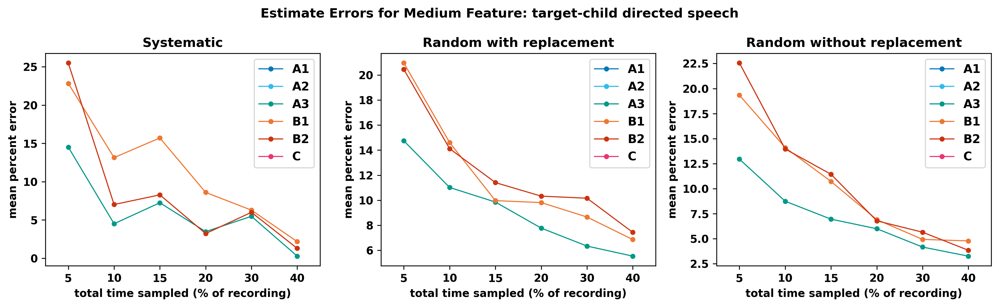

High   speech from FA1/MA1


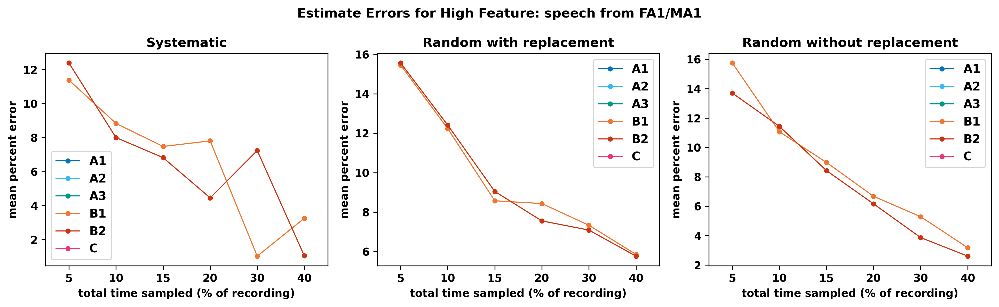

High   electronic source


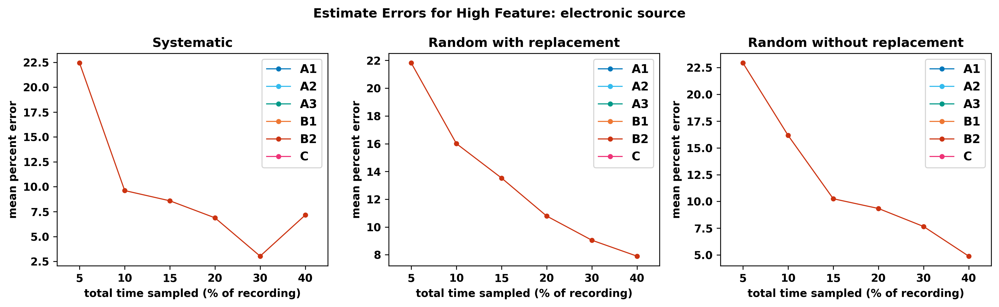

High   adult directed speech


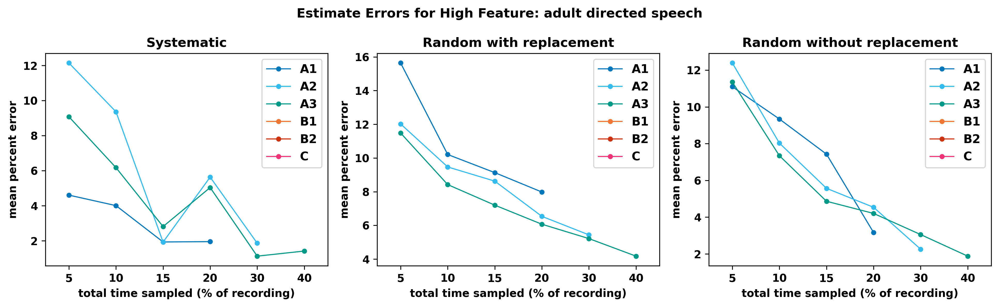

High   target-child directed speech


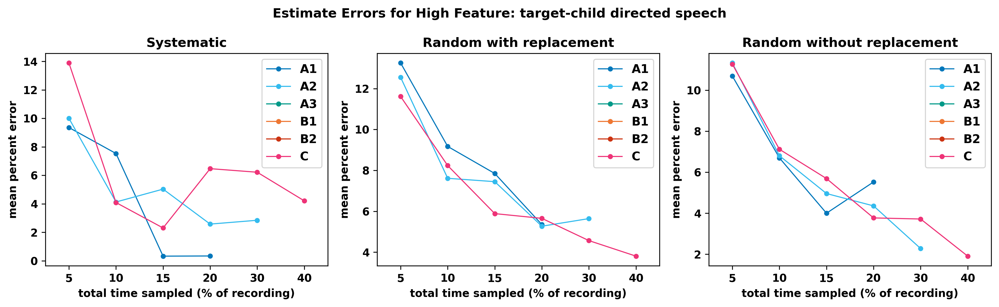

Very High   speech from FA1


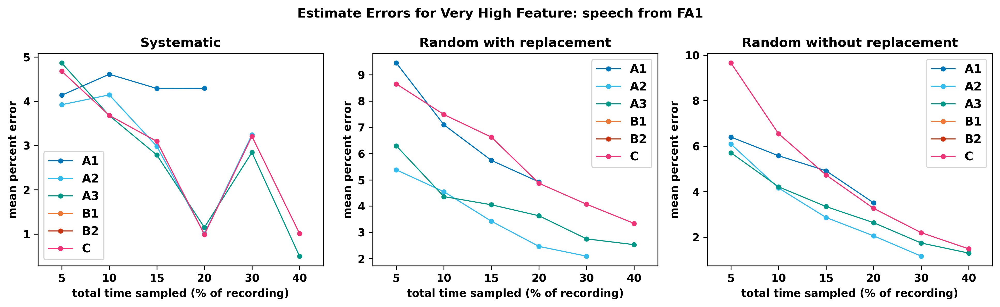

Very High   adult directed speech


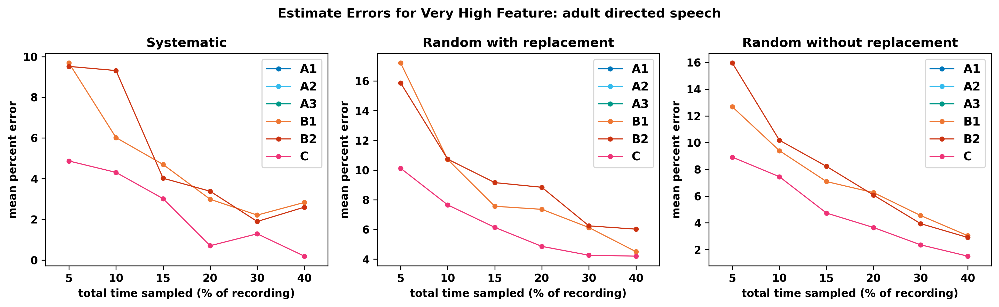

Very High   other-child directed speech


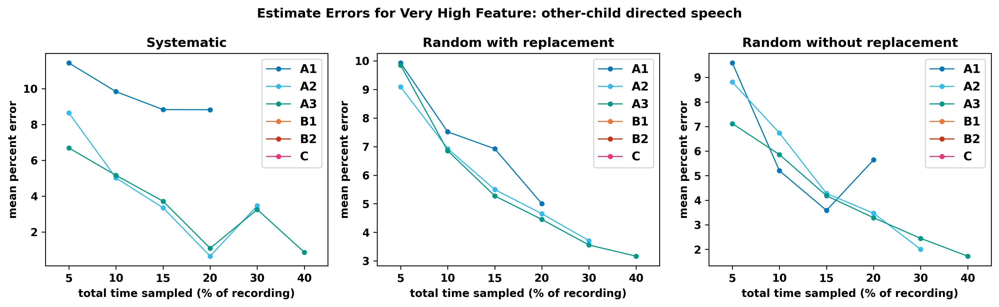

In [229]:
freqdensity = ["Rare", "Low", "Medium", "High", "Very High"]
fq = freqdensity[0]
#print(fq)
for fq in freqdensity:
    densitygrp = df_long[df_long["Frequency Density Group"] == fq]
    for feature in list(densitygrp["Feature"].unique()):
        #feat_perr = densitygrp[densitygrp["Feature"] == feature]
        #print(feature)
        make_crossprocedure_errorplots(df_long, feature = feature, feature_density_group= fq)

### frequency density values for select features

In [464]:
# get densities 
print("RARE DENSITY")
rare_density_dicts = [ {"select_word": "eat"}, {"utterance_annotation": "imit"}]
fd = get_feature_densities(rare_density_dicts)
print(f"\nGroup Mean: {statistics.mean(fd)*100:<5}% \tStdev: {statistics.stdev(fd)*100}%")

print("\nLOW DENSITY")
fd = get_feature_densities([{'utterance_annotation': '!'}], transcripts = [transcriptA1,transcriptA2,transcriptA3,transcriptB1], transcript_labels=['A1', 'A2', 'A3', 'B1'])
fd = fd + get_feature_densities([{"speaker":"CHI"}], transcripts = TRANSCRIPTS[0:5], transcript_labels=['A1', 'A2', 'A3', 'B1', 'B2'])
fd = fd + get_feature_densities([{'xds':'C'}], transcripts = [transcriptB2], transcript_labels=["B2"])
print(f"\nGroup Mean: {statistics.mean(fd)*100:<5}% \tStdev: {statistics.stdev(fd)*100}%")

print("\nMED DENSITY")
fd = get_feature_densities([{'utterance_annotation':'?'}], transcripts = TRANSCRIPTS[0:5],transcript_labels=['A1', 'A2', 'A3', 'B1', 'B2'])
fd = fd + get_feature_densities([{'speaker':'FC1'}], transcripts=[transcriptA1,transcriptC], transcript_labels=['A1','C'])
fd = fd + get_feature_densities([{'xds':'T'}], transcripts = [transcriptA3, transcriptB1,transcriptB2], transcript_labels=['A3', 'B1', 'B2'])
print(f"\nGroup Mean: {statistics.mean(fd)*100:<5}% \tStdev: {statistics.stdev(fd)*100}%")

print(('\nHIGH DENSITY'))
fd = get_feature_densities([{'xds':'T'}], transcripts = [transcriptA1, transcriptA2, transcriptC], transcript_labels=['A1','A2','C'])
fd = fd + get_feature_densities([{'speaker':"EE1"}], transcripts = [transcriptB2], transcript_labels=["B2"])
fd = fd +get_feature_densities([{'xds':"A"}], transcripts =[transcriptA1, transcriptA2,transcriptA3], transcript_labels=["A1", "A2", "A3"] )
fd = fd +get_feature_densities([{"speaker":"MA1"}], transcripts=[ transcriptB1], transcript_labels=['B1'])
fd = fd +get_feature_densities([{"speaker":"FA1"}], transcripts=[ transcriptB2], transcript_labels=['B2'])
print(f"\nGroup Mean: {statistics.mean(fd)*100:<5}% \tStdev: {statistics.stdev(fd)*100}%")

print('\nVERY HIGH DENSITY')
fd = get_feature_densities([{'xds':'C'}], transcripts = TRANSCRIPTS[0:3], transcript_labels=TRANSCRIPT_LABELS[0:3])
fd = fd +get_feature_densities([{'xds':"A"}], transcripts =[transcriptB1, transcriptB2,transcriptC], transcript_labels=["B1", "B2", "C"] )
fd = fd +get_feature_densities([{'speaker':"FA1"}], transcripts = TRANSCRIPTS[0:3]+TRANSCRIPTS[-1:], transcript_labels=["A1", "A2", "A3", "C"])
print(f"\nGroup Mean: {statistics.mean(fd)*100:<5}% \tStdev: {statistics.stdev(fd)*100}%")

RARE DENSITY
Feature densities for: select_word, eat
	A1   : 47    	 0.26994428809373383%
	A2   : 74    	 0.26312982256516015%
	A3   : 81    	 0.21022034206223558%
	B1   : 40    	 0.08476012883539584%
	B2   : 34    	 0.11341650543732071%
	C    : 39    	 0.13759040395131417%
	Overall: 0.1798435818241934% 	Stdev: 0.07901421806172512%
Feature densities for: utterance_annotation, imit
	A1   : 61    	 1.1207054932941392%
	A2   : 110   	 1.2458942122550685%
	A3   : 130   	 1.0553661308654003%
	B1   : 240   	 1.3699412066898795%
	B2   : 98    	 1.1435239206534422%
	Overall: 1.187086192751586% 	Stdev: 0.12303310814005379%

Group Mean: 0.6376811322457354% 	Stdev: 0.5346667891385356%

LOW DENSITY
Feature densities for: utterance_annotation, !
	A1   : 535   	 9.829138342825647%
	A2   : 596   	 6.750481368218371%
	A3   : 1071  	 8.694593278129567%
	B1   : 1467  	 8.37376562589189%
	Overall: 8.411994653766369% 	Stdev: 1.2715143300486558%
Feature densities for: speaker, CHI
	A1   : 1308  	 7.5124921

In [435]:
fd = get_feature_densities([{'speaker':"EE1"}], transcripts =TRANSCRIPTS, transcript_labels=TRANSCRIPT_LABELS )
print(f"\nGroup Mean: {statistics.mean(fd)*100:<5}% \tStdev: {statistics.stdev(fd)*100}%")
print()
fd = get_feature_densities([{'speaker':"FA2"}], transcripts =TRANSCRIPTS, transcript_labels=TRANSCRIPT_LABELS )
print(f"\nGroup Mean: {statistics.mean(fd)*100:<5}% \tStdev: {statistics.stdev(fd)*100}%")
print()
fd = get_feature_densities([{'utterance_annotation':"<"}], transcripts =TRANSCRIPTS, transcript_labels=TRANSCRIPT_LABELS )
print(f"\nGroup Mean: {statistics.mean(fd)*100:<5}% \tStdev: {statistics.stdev(fd)*100}%")
print()

Feature densities for: speaker, EE1
	A1   : 889   	 5.105967491815519%
	A2   : 340   	 1.2089748604345198%
	A3   : 503   	 1.3054423710778336%
	B1   : 3400  	 7.204610951008646%
	B2   : 8642  	 28.827807058509574%
	C    : 0     	 0.0%
	Overall: 7.275467122141016% 	Stdev: 10.90496264744418%

Group Mean: 7.275467122141016% 	Stdev: 10.90496264744418%

Feature densities for: speaker, FA2
	A1   : 0     	 0.0%
	A2   : 0     	 0.0%
	A3   : 35    	 0.0908359502738055%
	B1   : 8994  	 19.05831496863875%
	B2   : 3739  	 12.472479818533591%
	C    : 0     	 0.0%
	Overall: 5.270271789574358% 	Stdev: 8.392088953550598%

Group Mean: 5.270271789574358% 	Stdev: 8.392088953550598%

Feature densities for: utterance_annotation, <
	A1   : 1111  	 20.41153775491457%
	A2   : 1863  	 21.100917431192663%
	A3   : 325   	 2.6384153271635005%
	B1   : 3372  	 19.24767395399281%
	B2   : 2109  	 24.609101516919488%
	Overall: 17.601529196836605% 	Stdev: 8.600181759281737%

Group Mean: 17.601529196836605% 	Stdev: 8.60